# Exercise 8.6 — Q1: Quadratic Distribution with SVM

**Lab Book §8.6 Exercise 1 (page 37):**  
> Generate a random dataset that follows a quadratic distribution using SVM.

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** SVM with non-linear (quadratic) decision boundary  
**Dataset:** `datasets/quadratic_sample.csv` (200 rows × 3 cols)

---

## 🎯 Objective

Generate a 2-D random dataset whose true class boundary is a quadratic
curve (`y = x² − 1`).  Train an SVM with the RBF kernel and visualise
the resulting non-linear decision boundary.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `04_Q1_Quadratic_Distribution.ipynb` | This notebook |
| `datasets/quadratic_sample.csv` | 200-row quadratic-boundary dataset |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '04-SVM'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q1_Quadratic_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/04-SVM


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/04-SVM/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/quadratic_sample.csv')
print(f"Shape: {df.shape}")
display(df.head())
print("\nClass distribution:")
print(df['label'].value_counts())

Shape: (200, 3)


,x1,x2,label
0,1.644,1.664,0
1,-0.367,2.831,1
2,2.152,0.004,0
3,1.184,-2.137,0
4,-2.435,-2.916,0



Class distribution:
label
0    145
1     55
Name: count, dtype: int64


## 3. Define Features & Target

In [4]:
X = df[['x1', 'x2']].values
y = df['label'].values
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (200, 2), y shape: (200,)


## 4. Train/Test Split & Scaling

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print("Features standardised.")

Features standardised.


## 5. Train SVM with RBF Kernel

In [6]:
model = SVC(kernel='rbf', random_state=0)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print(f"Accuracy (RBF): {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy (RBF): 0.9500
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        44
           1       0.93      0.88      0.90        16

    accuracy                           0.95        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.95      0.95      0.95        60



## 6. Train SVM with Linear Kernel (for comparison)

In [7]:
model_lin = SVC(kernel='linear', random_state=0)
model_lin.fit(X_train_s, y_train)
y_pred_lin = model_lin.predict(X_test_s)
print(f"Accuracy (Linear): {accuracy_score(y_test, y_pred_lin):.4f}")
print("\nNote: linear kernel cannot capture the quadratic boundary well.")

Accuracy (Linear): 0.7833

Note: linear kernel cannot capture the quadratic boundary well.


## 7. Visualise Decision Boundary

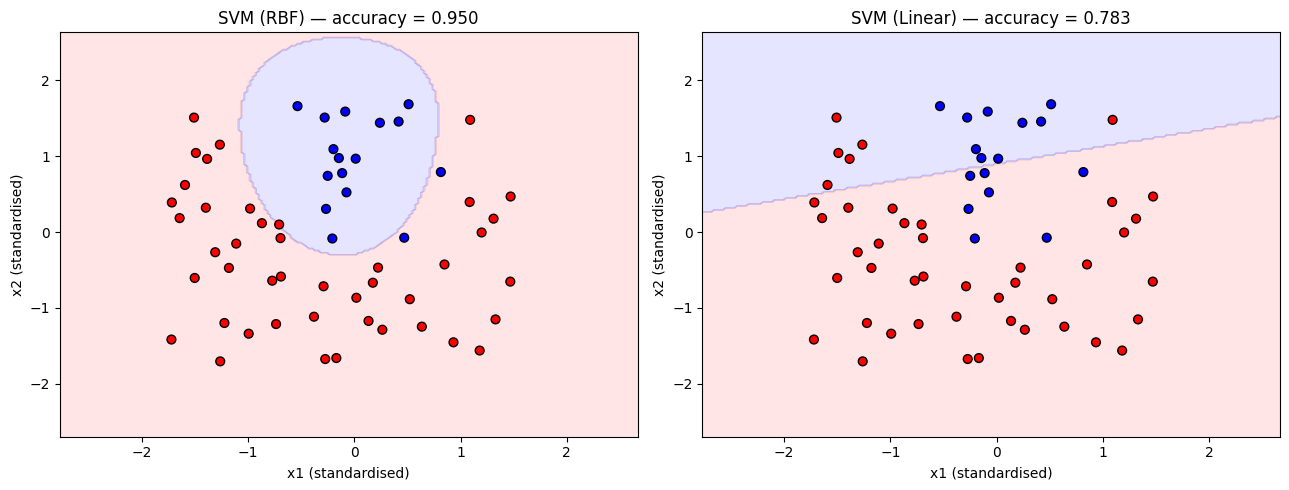

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kernel, name in zip(axes, ['rbf', 'linear'], ['RBF', 'Linear']):
    m = SVC(kernel=kernel, random_state=0).fit(X_train_s, y_train)
    x_min, x_max = X_train_s[:, 0].min()-1, X_train_s[:, 0].max()+1
    y_min, y_max = X_train_s[:, 1].min()-1, X_train_s[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAAAFF']))
    ax.scatter(X_test_s[:, 0], X_test_s[:, 1], c=y_test,
               cmap=ListedColormap(['#FF0000','#0000FF']),
               edgecolors='k', s=40)
    acc = accuracy_score(y_test, m.predict(X_test_s))
    ax.set_title(f'SVM ({name}) — accuracy = {acc:.3f}')
    ax.set_xlabel('x1 (standardised)')
    ax.set_ylabel('x2 (standardised)')
plt.tight_layout()
plt.show()

## 📚 Key Takeaways
- The RBF kernel **captures** the quadratic decision boundary.
- The linear kernel **fails** — confirming that non-linear boundaries
  require a non-linear kernel.
- Always plot the decision boundary when working with 2-D toy datasets —
  it makes the difference between kernels immediately visible.
